# EDA - Censo de Pessoas em Situacao de Rua (CPSR 2020/2022/2024)

Este notebook explora o **Censo de Pessoas em Situacao de Rua (PSR)** da Prefeitura do Rio de Janeiro, realizado de forma trienal nos anos **2020, 2022 e 2024**.

**Contexto CompStat.** A PSR e um dos 20 **fatores urbanos** mapeados pelo CompStat, sob responsabilidade da **Secretaria Municipal de Assistencia Social (SMAS)**. O cruzamento da concentracao de PSR com *hot-spots* criminais ajuda a decidir onde a SMAS deve atuar: acolhimento, realocacao, abordagem social, resposta a cenas de uso de drogas. Os achados deste EDA tambem alimentam a analise qualitativa das **RELINTs**.

**Dataset:** `dados/outros dados/CPSR_2020_2022_2024.xlsx`, planilha unica `Censo_historico`. Cada linha = uma pessoa entrevistada em uma das tres edicoes.

**Roteiro**
1. Carga e esquema.
2. Evolucao temporal (2020 → 2022 → 2024).
3. Dimensao geografica (bairros, RP, AP) + mapa com poligonos da Forca Municipal (FM).
4. Demografia (sexo, genero, faixa etaria, cor/raca).
5. Motivos, tempo de rua e cena de uso.
6. Contagem de PSR dentro de cada poligono FM.
7. Conclusoes.


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.environ.get('TMPDIR', '/tmp'), 'matplotlib'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

REPO = '/Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio'
XLSX = f'{REPO}/dados/outros dados/CPSR_2020_2022_2024.xlsx'
SHP  = f'{REPO}/sh_area_forca/areas_forca_municipal.shp'
print('XLSX:', XLSX)
print('SHP :', SHP)


XLSX: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/dados/outros dados/CPSR_2020_2022_2024.xlsx
SHP : /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/sh_area_forca/areas_forca_municipal.shp


## 2. Carga e esquema

Lendo a planilha `Censo_historico` e inspecionando estrutura **sem assumir nada** sobre colunas.


In [2]:
df = pd.read_excel(XLSX, sheet_name='Censo_histórico')
print('shape:', df.shape)
print('memoria:', round(df.memory_usage(deep=True).sum() / 1024**2, 1), 'MB')


shape: (23332, 167)
memoria: 215.4 MB


In [3]:
# Lista completa de colunas
cols = list(df.columns)
print(f'Total de colunas: {len(cols)}')
for i, c in enumerate(cols):
    print(f'{i:3d}. {c!r}')


Total de colunas: 167
  0. 'Chave_única'
  1. 'Rua_Acolhimento'
  2. 'Local da coleta de dados'
  3. 'Nome da Instituição'
  4. 'Método'
  5. 'Instrumento de coleta'
  6. 'Latitude'
  7. 'Longitude'
  8. 'Situação_entrevista'
  9. 'Motivo_situação'
 10. 'Faixa etária'
 11. 'Classificação idade'
 12. 'Dormiu_rua'
 13. 'Sexo'
 14. 'Gênero'
 15. 'Cor_raça'
 16. 'Possui animal de estimação?'
 17. 'Caminhar ou subir degraus'
 18. 'Enxergar, mesmo que com óculos ou lentes de contato'
 19. 'Ouvir, mesmo que com aparelho '
 20. 'Possui alguma deficiência mental? Dificuldade em aprender, trabalhar, se comunicar com outros etc. '
 21. 'Não possui nenhuma deficiência'
 22. 'NS/NR'
 23. 'Certidão de Nascimento'
 24. 'CPF'
 25. 'Carteira de Identidade'
 26. 'Carteira de Trabalho'
 27. 'Título de Eleitor'
 28. 'Passaporte'
 29. 'RED'
 30. 'Naturalidade'
 31. 'Estado'
 32. 'Município'
 33. 'Voltar_cidade_natal'
 34. 'Contato_família'
 35. 'Contato_família_complemento'
 36. 'Dorme_rua_acolhimento'
 37

In [4]:
# dtypes
df.dtypes.value_counts()


,count
str,160
int64,4
float64,2
object,1


In [5]:
# Primeiras linhas (mostra subset de colunas-chave)
key_cols = ['Ano', 'Latitude', 'Longitude', 'Nome do Bairro', 'Área de Planejamento_3',
            'RP', 'Sexo', 'Gênero', 'Faixa etária', 'Cor_raça']
df[key_cols].head(20)


,Ano,Latitude,Longitude,Nome do Bairro,Área de Planejamento_3,RP,Sexo,Gênero,Faixa etária,Cor_raça
0,2020,-22.917108,-43.634687,Paciência,AP5,5.3 - Santa Cruz,Masculino,Homem Cis,18 a 30,Preta
1,2020,-22.901543,-43.558147,Campo Grande,AP5,5.2 - Campo Grande,Masculino,Homem Cis,31 a 49,Preta
2,2020,-22.901599,-43.558115,Campo Grande,AP5,5.2 - Campo Grande,Masculino,Homem Cis,31 a 49,Preta
3,2020,-22.904111,-43.555531,Campo Grande,AP5,5.2 - Campo Grande,Feminino,Mulher Cis,50 a 59,Branca
4,2020,-22.907769,-43.563940,Campo Grande,AP5,5.2 - Campo Grande,Masculino,Homem Cis,31 a 49,Preta
5,2020,-22.907664,-43.563940,Campo Grande,AP5,5.2 - Campo Grande,Masculino,Homem Cis,31 a 49,Parda
6,2020,-23.025674,-43.488271,Recreio dos Bandeirantes,AP4,4.2 - Barra da Tijuca,Masculino,Homem Cis,31 a 49,Parda
7,2020,-23.026735,-43.484904,Recreio dos Bandeirantes,AP4,4.2 - Barra da Tijuca,Masculino,Homem Cis,50 a 59,Branca
8,2020,-23.028273,-43.473435,Recreio dos Bandeirantes,AP4,4.2 - Barra da Tijuca,Feminino,Mulher Cis,31 a 49,Preta
9,2020,-23.034125,-43.492472,Recreio dos Bandeirantes,AP4,4.2 - Barra da Tijuca,Masculino,Homem Cis,31 a 49,Parda


In [6]:
# Missing por coluna (somente as com pelo menos 1 missing)
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]
print(f'{len(miss)} colunas com missing (de {df.shape[1]})')
miss.head(30)


144 colunas com missing (de 167)


,0
NS/NR.2,20783
Problemas psiquiátricos,19297
Nome da Instituição,17445
Alimentos,16060
Ajuda_pandemia,16060
Por_quê,16060
Rua_início_coronavírus,16060
Itens_higiene_pessoal,16060
Máscaras_proteção,16060
Residência_fixa_complemento,16060


## 3. Evolucao temporal

A planilha tem coluna `Ano` (2020, 2022, 2024). Cada linha = 1 pessoa, entao a contagem de PSR por ano e a contagem de linhas.


In [7]:
totais = df.groupby('Ano').size().rename('PSR').to_frame()
totais['delta_abs'] = totais['PSR'].diff()
totais['delta_pct'] = totais['PSR'].pct_change() * 100
totais


,PSR,delta_abs,delta_pct
Ano,,,
2020,7272,NaN,NaN
2022,7865,593.0,8.154565
2024,8195,330.0,4.195804


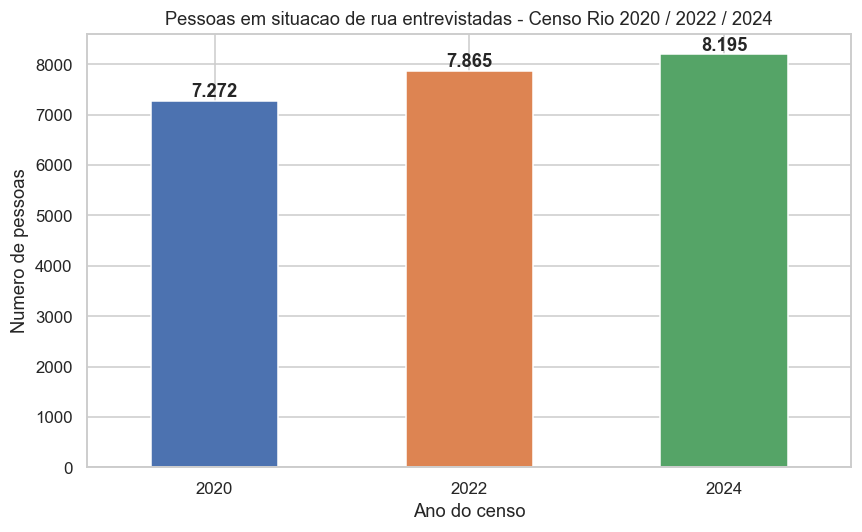

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
totais['PSR'].plot(kind='bar', color=['#4c72b0', '#dd8452', '#55a467'], ax=ax)
for i, v in enumerate(totais['PSR']):
    ax.text(i, v + 80, f'{v:,}'.replace(',', '.'), ha='center', fontweight='bold')
ax.set_title('Pessoas em situacao de rua entrevistadas - Censo Rio 2020 / 2022 / 2024')
ax.set_xlabel('Ano do censo')
ax.set_ylabel('Numero de pessoas')
ax.set_xticklabels([str(int(x)) for x in totais.index], rotation=0)
plt.tight_layout(); plt.show()


In [9]:
# Variacao acumulada 2020 -> 2024
v2020 = int(totais.loc[2020, 'PSR'])
v2024 = int(totais.loc[2024, 'PSR'])
print(f'2020: {v2020:,}'.replace(',', '.'))
print(f'2024: {v2024:,}'.replace(',', '.'))
print(f'Variacao 2020 -> 2024: {(v2024 - v2020):+,} pessoas ({(v2024/v2020 - 1)*100:+.1f}%)'.replace(',', '.'))


2020: 7.272
2024: 8.195
Variacao 2020 -> 2024: +923 pessoas (+12.7%)


## 4. Dimensao geografica

Existem colunas `Latitude`, `Longitude`, `Nome do Bairro`, `RP` (Regiao de Planejamento), `Área de Planejamento_3` (AP1-AP5) e `Região Administrativa_4`. Vamos olhar todas.


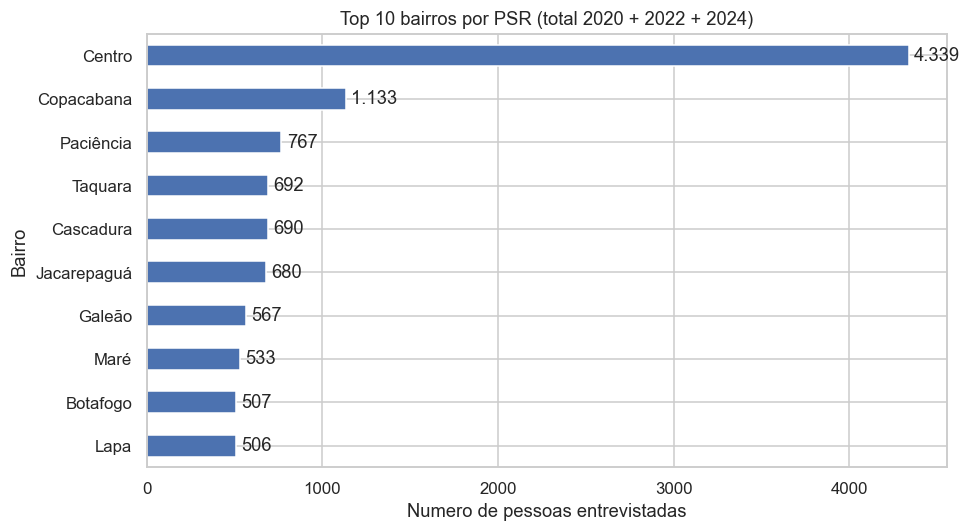

In [10]:
# Top-10 bairros (total 2020-2024)
top_bairros = df['Nome do Bairro'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
top_bairros.iloc[::-1].plot(kind='barh', ax=ax, color='#4c72b0')
ax.set_title('Top 10 bairros por PSR (total 2020 + 2022 + 2024)')
ax.set_xlabel('Numero de pessoas entrevistadas')
ax.set_ylabel('Bairro')
for i, v in enumerate(top_bairros.iloc[::-1]):
    ax.text(v + 30, i, f'{v:,}'.replace(',', '.'), va='center')
plt.tight_layout(); plt.show()


In [11]:
# Evolucao dos top-10 bairros por ano
top10 = top_bairros.index.tolist()
evo_bairros = (df[df['Nome do Bairro'].isin(top10)]
               .groupby(['Ano', 'Nome do Bairro']).size()
               .unstack(fill_value=0)
               [top10])
evo_bairros


Nome do Bairro,Centro,Copacabana,Paciência,Taquara,Cascadura,Jacarepaguá,Galeão,Maré,Botafogo,Lapa
Ano,,,,,,,,,,
2020,1442,463,210,98,59,229,180,146,108,243
2022,1452,329,327,347,25,66,217,206,206,119
2024,1445,341,230,247,606,385,170,181,193,144


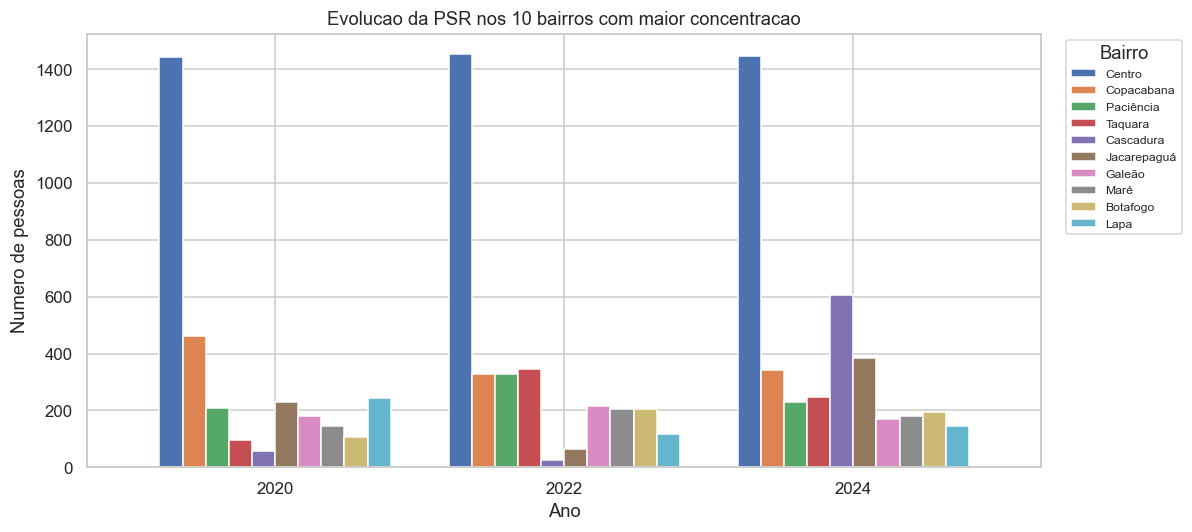

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
evo_bairros.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Evolucao da PSR nos 10 bairros com maior concentracao')
ax.set_xlabel('Ano'); ax.set_ylabel('Numero de pessoas')
ax.set_xticklabels([str(int(x)) for x in evo_bairros.index], rotation=0)
ax.legend(title='Bairro', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


In [13]:
# Distribuicao por Area de Planejamento (AP)
ap = df.groupby(['Ano', 'Área de Planejamento_3']).size().unstack(fill_value=0)
ap


Área de Planejamento_3,AP1,AP2,AP3,AP4,AP5
Ano,,,,,
2020,2317,1482,1927,634,912
2022,2220,1463,2380,745,1057
2024,2204,1308,2895,931,857


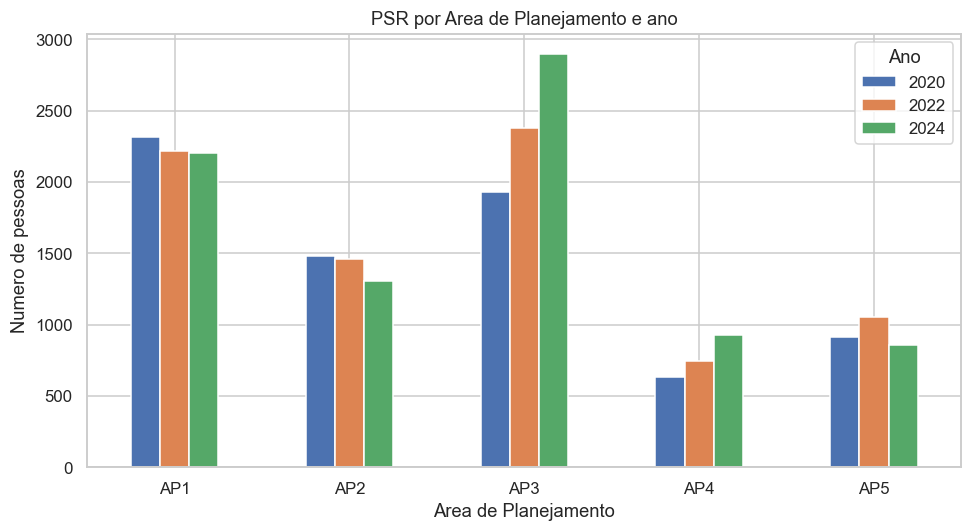

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ap.T.plot(kind='bar', ax=ax)
ax.set_title('PSR por Area de Planejamento e ano')
ax.set_xlabel('Area de Planejamento'); ax.set_ylabel('Numero de pessoas')
ax.legend(title='Ano')
ax.set_xticklabels(ap.columns, rotation=0)
plt.tight_layout(); plt.show()


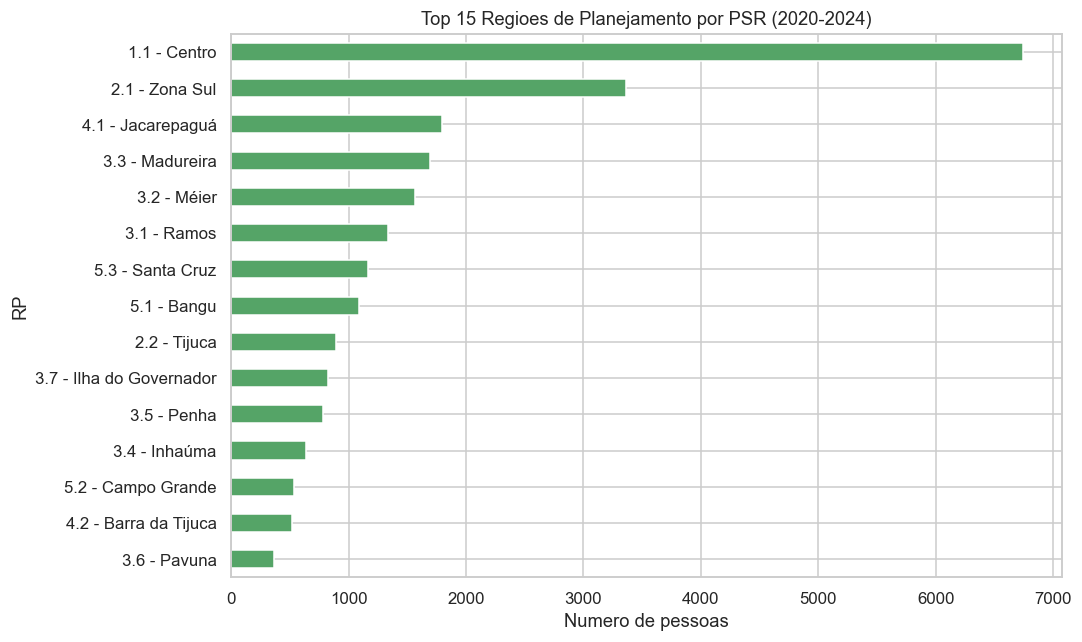

In [15]:
# Top-15 RPs (Regioes de Planejamento)
rp = df['RP'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
rp.iloc[::-1].plot(kind='barh', ax=ax, color='#55a467')
ax.set_title('Top 15 Regioes de Planejamento por PSR (2020-2024)')
ax.set_xlabel('Numero de pessoas')
plt.tight_layout(); plt.show()


### 4.1 Mapa: PSR + poligonos da Forca Municipal

Sobreposicao dos pontos PSR com as 8 areas FM (`sh_area_forca/areas_forca_municipal.shp`, EPSG:4326). Para legibilidade, o scatter usa amostragem aleatoria de 8.000 pontos.


In [16]:
fm = gpd.read_file(SHP)
print('FM CRS:', fm.crs)
print('FM count:', len(fm))
fm[['fid', 'nome_subar']]


FM CRS: EPSG:4326
FM count: 8


,fid,nome_subar
0,2.0,Rodoviária - Terminal Gentileza - Estação Leopoldina
1,9.0,Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria
2,10.0,Jardim de Alah
3,11.0,Campo Grande: Estação de Trem - Calçadão
4,12.0,Rio Sul
5,14.0,Praia de Botafogo - Rua Marquês de Abrantes
6,19.0,Estações São Francisco Xavier - Afonso Pena
7,20.0,Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia


pontos validos: 23332


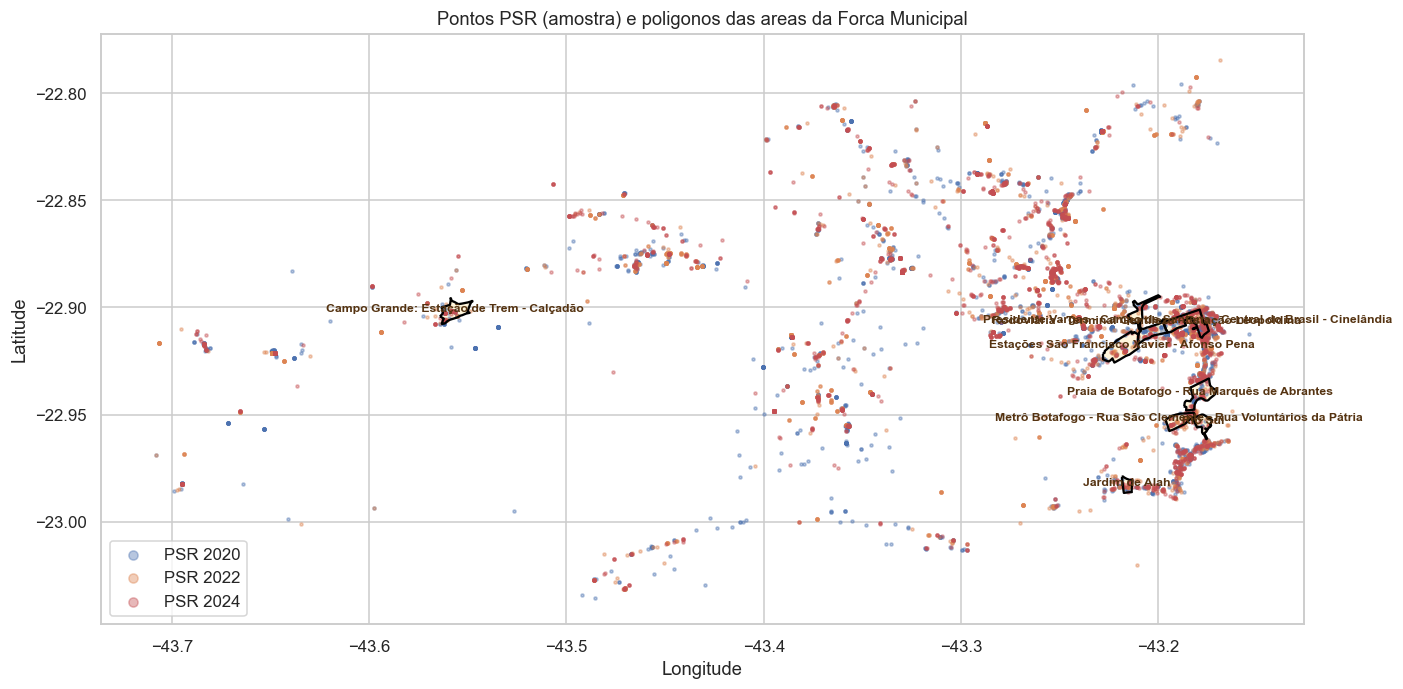

In [17]:
# Filtrar coordenadas validas (dentro do bounding-box do Rio)
geo = df[['Ano', 'Latitude', 'Longitude']].copy()
geo = geo.dropna()
geo = geo[(geo['Latitude'].between(-23.1, -22.7)) & (geo['Longitude'].between(-43.8, -43.1))]
print('pontos validos:', len(geo))

fig, ax = plt.subplots(figsize=(13, 9))
fm.boundary.plot(ax=ax, color='black', linewidth=1.5)
fm.plot(ax=ax, color='#ffe39a', alpha=0.35)
# rotular FM
for _, r in fm.iterrows():
    c = r.geometry.centroid
    ax.annotate(str(r['nome_subar']), (c.x, c.y), fontsize=8, ha='center',
                fontweight='bold', color='#553311')

colors = {2020: '#4c72b0', 2022: '#dd8452', 2024: '#c44e52'}
for y in sorted(geo['Ano'].unique()):
    sub = geo[geo['Ano'] == y].sample(min(3000, len(geo[geo['Ano'] == y])), random_state=42)
    ax.scatter(sub['Longitude'], sub['Latitude'], s=4, alpha=0.4,
               color=colors[y], label=f'PSR {int(y)}')

ax.set_title('Pontos PSR (amostra) e poligonos das areas da Forca Municipal')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='lower left', markerscale=3)
plt.tight_layout(); plt.show()


## 5. Demografia

Eixos disponiveis no esquema: `Sexo`, `Gênero`, `Faixa etária`, `Cor_raça`.


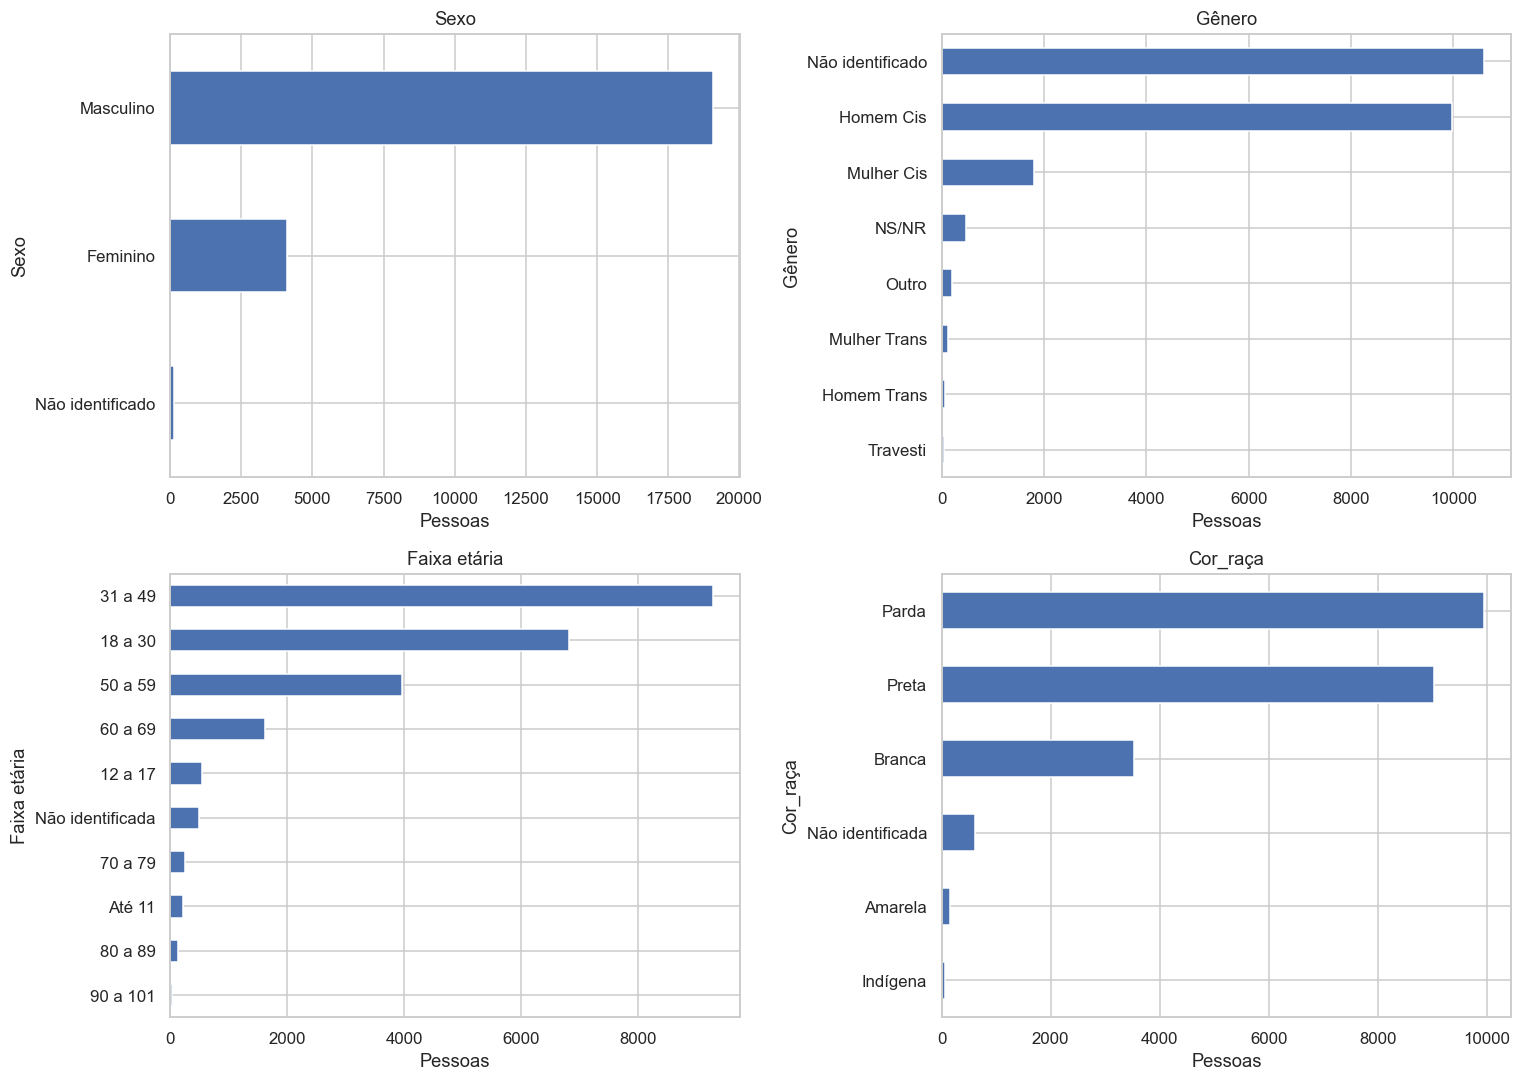

In [18]:
def normalize(series):
    return series.astype(str).str.strip()

dem_cols = ['Sexo', 'Gênero', 'Faixa etária', 'Cor_raça']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, dem_cols):
    vc = normalize(df[col]).value_counts().head(10)
    vc.iloc[::-1].plot(kind='barh', ax=ax, color='#4c72b0')
    ax.set_title(col)
    ax.set_xlabel('Pessoas')
plt.tight_layout(); plt.show()


In [19]:
# Faixa etaria por ano (ordenada)
ordem_idade = ['Até 11', '12 a 17', '18 a 30', '31 a 49', '50 a 59',
               '60 a 69', '70 a 79', '80 a 89', '90 a 101', 'Não identificada']
idade = (df.groupby(['Ano', 'Faixa etária']).size()
         .unstack(fill_value=0))
idade = idade[[c for c in ordem_idade if c in idade.columns]]
idade


Faixa etária,Até 11,12 a 17,18 a 30,31 a 49,50 a 59,60 a 69,70 a 79,80 a 89,90 a 101,Não identificada
Ano,,,,,,,,,,
2020,112,220,2128,2650,1250,511,95,43,15,248
2022,76,183,2384,3184,1301,547,77,55,6,52
2024,34,134,2302,3445,1406,556,84,32,3,199


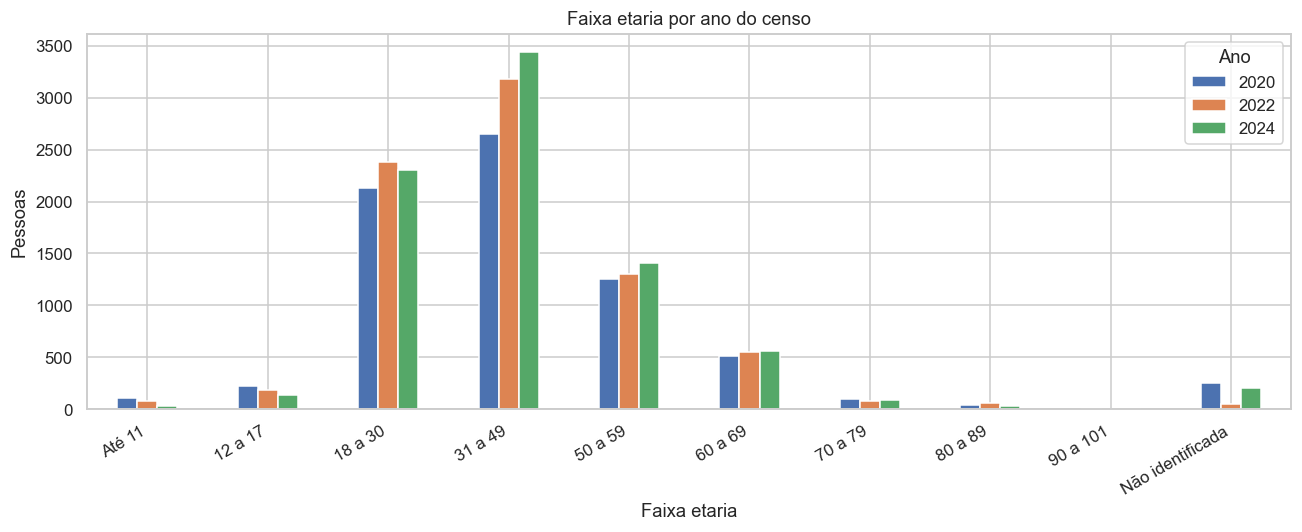

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
idade.T.plot(kind='bar', ax=ax)
ax.set_title('Faixa etaria por ano do censo')
ax.set_xlabel('Faixa etaria'); ax.set_ylabel('Pessoas')
ax.set_xticklabels(idade.columns, rotation=30, ha='right')
ax.legend(title='Ano')
plt.tight_layout(); plt.show()


In [21]:
# Cor/raca: distribuicao percentual por ano
cr = df.groupby(['Ano', 'Cor_raça']).size().unstack(fill_value=0)
cr_pct = cr.div(cr.sum(axis=1), axis=0) * 100
cr_pct.round(1)


Cor_raça,Amarela,Branca,Indígena,Não identificada,Parda,Preta
Ano,,,,,,
2020,1.3,18.0,0.3,4.3,37.9,38.2
2022,0.3,13.1,0.3,1.7,43.2,41.4
2024,0.4,14.4,0.3,2.0,46.3,36.6


## 6. Motivos para estar na rua e tempo de permanencia

Colunas `Motivo_dormir_rua` e `Tempo_rua_RJ`. Como nao se aplicam a entrevistados acolhidos, filtramos os valores informativos.


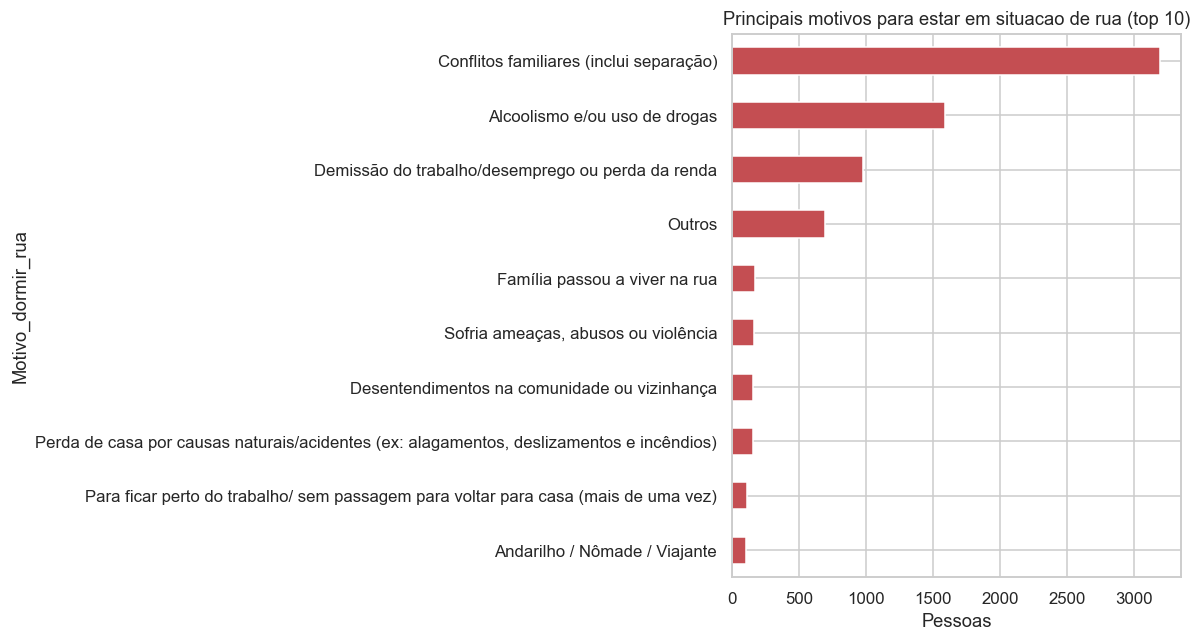

In [22]:
def clean(series):
    s = series.astype(str).str.strip()
    s = s.replace({'nan': np.nan, 'Não se aplica': np.nan, 'NS/NR': np.nan})
    return s

motivo = clean(df['Motivo_dormir_rua']).str.replace(
    'Demissão do trabalho/desemprego ou perda de renda',
    'Demissão do trabalho/desemprego ou perda da renda'
)
top_motivos = motivo.value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
top_motivos.iloc[::-1].plot(kind='barh', ax=ax, color='#c44e52')
ax.set_title('Principais motivos para estar em situacao de rua (top 10)')
ax.set_xlabel('Pessoas')
plt.tight_layout(); plt.show()


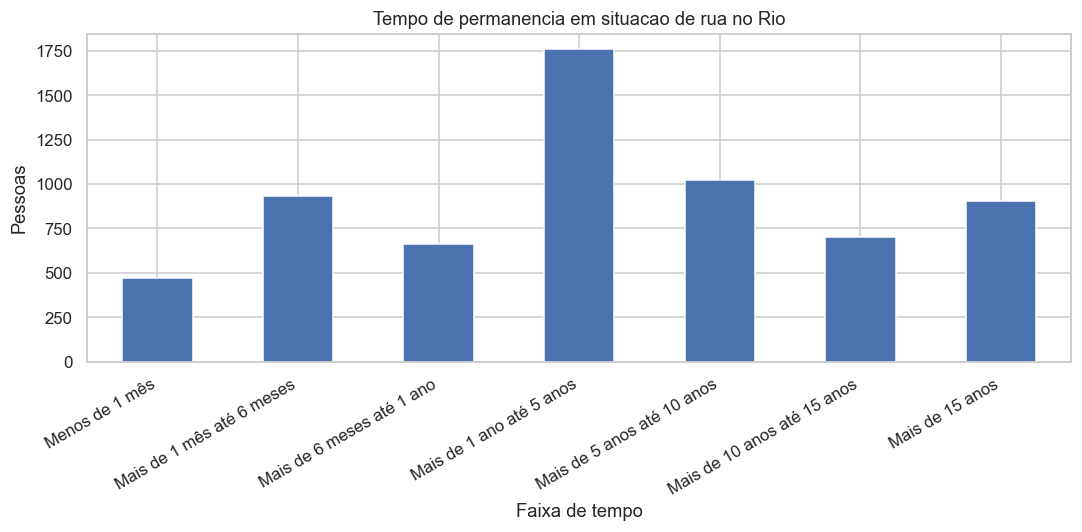

In [23]:
# Tempo de rua
ordem_tempo = ['Menos de 1 mês', 'Mais de 1 mês até 6 meses', 'Mais de 6 meses até 1 ano',
               'Mais de 1 ano até 5 anos', 'Mais de 5 anos até 10 anos',
               'Mais de 10 anos até 15 anos', 'Mais de 15 anos']
tempo = clean(df['Tempo_rua_RJ']).value_counts()
tempo = tempo[[c for c in ordem_tempo if c in tempo.index]]

fig, ax = plt.subplots(figsize=(10, 5))
tempo.plot(kind='bar', ax=ax, color='#4c72b0')
ax.set_title('Tempo de permanencia em situacao de rua no Rio')
ax.set_xlabel('Faixa de tempo'); ax.set_ylabel('Pessoas')
ax.set_xticklabels(tempo.index, rotation=30, ha='right')
plt.tight_layout(); plt.show()


## 7. Contagem de PSR dentro das areas da Forca Municipal

Spatial join entre os pontos PSR (lat/lon) e os 8 poligonos FM.


In [24]:
pts = df.dropna(subset=['Latitude', 'Longitude']).copy()
pts = pts[(pts['Latitude'].between(-23.1, -22.7)) & (pts['Longitude'].between(-43.8, -43.1))]
gdf = gpd.GeoDataFrame(pts,
                       geometry=gpd.points_from_xy(pts['Longitude'], pts['Latitude']),
                       crs='EPSG:4326')
print('pontos:', len(gdf))

joined = gpd.sjoin(gdf[['Ano', 'geometry']], fm[['fid', 'nome_subar', 'geometry']],
                   how='left', predicate='within')
within = joined.dropna(subset=['nome_subar'])
print('pontos dentro de alguma area FM:', len(within), f'({len(within)/len(gdf)*100:.1f}%)')


pontos: 23332
pontos dentro de alguma area FM: 3169 (13.6%)


In [25]:
# Contagem total por area FM
fm_tot = within.groupby('nome_subar').size().sort_values(ascending=False).rename('PSR_total')
fm_tot


,PSR_total
nome_subar,
Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia,1883
Rodoviária - Terminal Gentileza - Estação Leopoldina,333
Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria,255
Estações São Francisco Xavier - Afonso Pena,222
Campo Grande: Estação de Trem - Calçadão,181
Praia de Botafogo - Rua Marquês de Abrantes,158
Jardim de Alah,100
Rio Sul,37


In [26]:
# Evolucao por ano em cada area FM
fm_evo = within.groupby(['nome_subar', 'Ano']).size().unstack(fill_value=0)
fm_evo['total'] = fm_evo.sum(axis=1)
fm_evo = fm_evo.sort_values('total', ascending=False)
fm_evo


Ano,2020,2022,2024,total
nome_subar,,,,
Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia,476,806,601,1883
Rodoviária - Terminal Gentileza - Estação Leopoldina,131,107,95,333
Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria,36,132,87,255
Estações São Francisco Xavier - Afonso Pena,77,79,66,222
Campo Grande: Estação de Trem - Calçadão,57,48,76,181
Praia de Botafogo - Rua Marquês de Abrantes,60,24,74,158
Jardim de Alah,25,33,42,100
Rio Sul,12,12,13,37


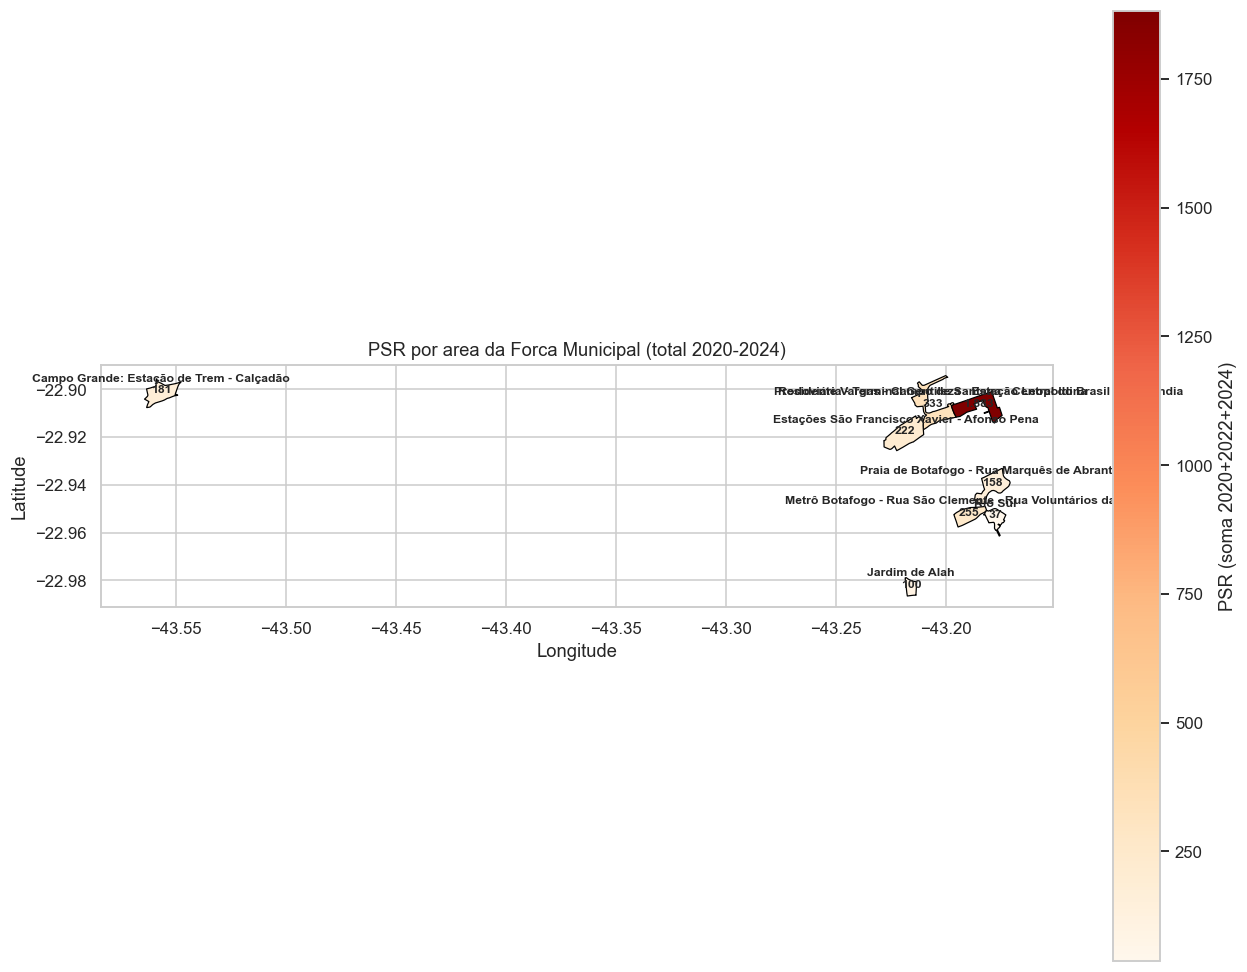

In [27]:
# Choropleth: total PSR por area FM
fm_map = fm.merge(fm_tot.reset_index(), on='nome_subar', how='left').fillna({'PSR_total': 0})

fig, ax = plt.subplots(figsize=(12, 9))
fm_map.plot(column='PSR_total', cmap='OrRd', edgecolor='black', linewidth=0.8,
            legend=True, ax=ax, legend_kwds={'label': 'PSR (soma 2020+2022+2024)'})
for _, r in fm_map.iterrows():
    c = r.geometry.centroid
    label = f"{r['nome_subar']}\n{int(r['PSR_total']):,}".replace(',', '.')
    ax.annotate(label, (c.x, c.y), fontsize=8, ha='center', fontweight='bold')
ax.set_title('PSR por area da Forca Municipal (total 2020-2024)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()


In [28]:
# Variacao 2020 -> 2024 dentro de cada FM
fm_delta = fm_evo[[c for c in [2020, 2022, 2024] if c in fm_evo.columns]].copy()
fm_delta['delta_2020_2024'] = fm_delta[2024] - fm_delta[2020]
fm_delta['delta_pct'] = ((fm_delta[2024] / fm_delta[2020].replace(0, np.nan)) - 1) * 100
fm_delta.round(1)


Ano,2020,2022,2024,delta_2020_2024,delta_pct
nome_subar,,,,,
Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia,476,806,601,125,26.3
Rodoviária - Terminal Gentileza - Estação Leopoldina,131,107,95,-36,-27.5
Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria,36,132,87,51,141.7
Estações São Francisco Xavier - Afonso Pena,77,79,66,-11,-14.3
Campo Grande: Estação de Trem - Calçadão,57,48,76,19,33.3
Praia de Botafogo - Rua Marquês de Abrantes,60,24,74,14,23.3
Jardim de Alah,25,33,42,17,68.0
Rio Sul,12,12,13,1,8.3


## 8. Conclusoes

Sintese dos achados (numeros recalculados dinamicamente abaixo):


In [29]:
tot_20 = int(totais.loc[2020, 'PSR'])
tot_22 = int(totais.loc[2022, 'PSR'])
tot_24 = int(totais.loc[2024, 'PSR'])
crescimento_pct = (tot_24/tot_20 - 1) * 100

top_b = top_bairros.head(3)
top_ap = ap.sum(axis=0).sort_values(ascending=False)
top_fm = fm_tot.head(3)
top_motivo = top_motivos.head(3)

print('1. Evolucao geral')
print(f'   2020: {tot_20:,}  |  2022: {tot_22:,}  |  2024: {tot_24:,}'.replace(',', '.'))
print(f'   Crescimento 2020 -> 2024: {crescimento_pct:+.1f}%')
print()
print('2. Concentracao por bairro (top 3, total trienio):')
for b, v in top_b.items():
    print(f'   - {b}: {v:,}'.replace(',', '.'))
print()
print('3. Top Areas de Planejamento (somando os 3 censos):')
for k, v in top_ap.head(3).items():
    print(f'   - {k}: {v:,}'.replace(',', '.'))
print()
print('4. Areas da Forca Municipal com maior concentracao de PSR:')
for k, v in top_fm.items():
    print(f'   - {k}: {int(v):,}'.replace(',', '.'))
print()
print('5. Motivos predominantes para estar na rua:')
for m, v in top_motivo.items():
    print(f'   - {m}: {v:,}'.replace(',', '.'))


1. Evolucao geral
   2020: 7.272  |  2022: 7.865  |  2024: 8.195
   Crescimento 2020 -> 2024: +12.7%

2. Concentracao por bairro (top 3, total trienio):
   - Centro: 4.339
   - Copacabana: 1.133
   - Paciência: 767

3. Top Areas de Planejamento (somando os 3 censos):
   - AP3: 7.202
   - AP1: 6.741
   - AP2: 4.253

4. Areas da Forca Municipal com maior concentracao de PSR:
   - Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia: 1.883
   - Rodoviária - Terminal Gentileza - Estação Leopoldina: 333
   - Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria: 255

5. Motivos predominantes para estar na rua:
   - Conflitos familiares (inclui separação): 3.190
   - Alcoolismo e/ou uso de drogas: 1.586
   - Demissão do trabalho/desemprego ou perda da renda: 975


### Takeaways operacionais para CompStat / SMAS

1. **A populacao em situacao de rua cresceu de forma sustentada** entre 2020 e 2024 (variacao calculada acima). A pressao sobre a rede de acolhimento e crescente e nao pontual.
2. **Concentracao extrema no Centro.** O bairro Centro lidera com folga em todos os censos; junto com Copacabana, Lapa e bairros da AP1, define o foco prioritario para SMAS - sobreposto a regioes com alta incidencia de roubo a transeunte.
3. **AP1 (Centro) e AP3 (Zona Norte)** concentram a maior parte das PSR; AP4 (Barra) tem a menor presenca relativa.
4. **Areas FM ja existentes capturam parcela relevante dos pontos PSR**, principalmente as do Centro/Lapa e da Zona Sul. Isto reforca que as decisoes da FM tem impacto direto sobre territorio com alta densidade de PSR - exigindo articulacao com SMAS antes de operacoes.
5. **Motivos predominantes (conflito familiar e uso de drogas/alcool)** indicam que a resposta operacional deve ser sociossanitaria, nao policial: cenas de uso pedem CAPS-AD e abordagem social, nao remocao.

Estes recortes alimentam diretamente: (i) a priorizacao de territorio para abordagem da SMAS, (ii) o cruzamento com hot-spots de crime nas RELINTs e (iii) o calibre dos indicadores do painel CompStat para o fator urbano *Populacao em situacao de rua*.
